In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, MinMaxScaler, LabelEncoder

In [12]:
# Generar un DataFrame más grande y equilibrado
n = 40
seniority_levels = ["Junior", "Mid", "Senior", "Lead"]
df = pd.DataFrame({
    "Salary": np.random.randint(20000, 60001, n),
    "Age": np.random.randint(22, 61, n),
    "Seniority": np.random.choice(seniority_levels, n)
})

In [13]:
# 1. dividir en train (70 %) y test (30 %)
train, test = train_test_split(df, test_size=0.3, random_state=42)

In [14]:
# LabelEncoder sobre Seniority, ajustado con train
le = LabelEncoder()

train["Seniority"] = le.fit_transform(train["Seniority"])  # fit + transform
test["Seniority"]  = le.transform(test["Seniority"])       #  transform

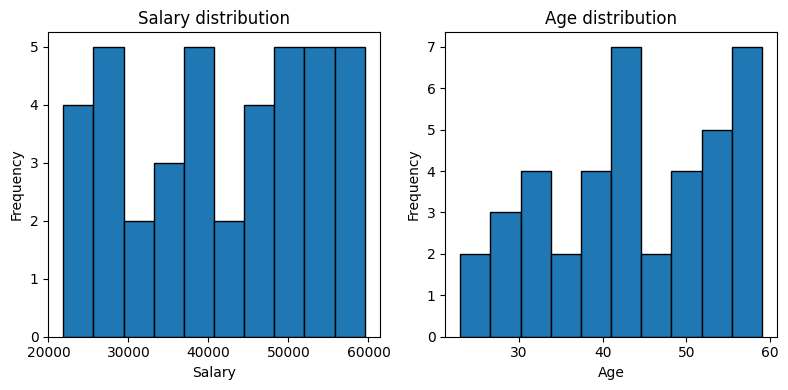

In [15]:
import matplotlib.pyplot as plt

# Histograma de Salary y Age antes de escalar
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].hist(df["Salary"], bins=10, edgecolor="black")
axes[0].set_title("Salary distribution")
axes[0].set_xlabel("Salary")
axes[0].set_ylabel("Frequency")

axes[1].hist(df["Age"], bins=10, edgecolor="black")
axes[1].set_title("Age distribution")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Con los histogramas vistos, ambos escalados funcionarían, así que la elección depende más del algoritmo.

In [16]:
# Escalado con StandardScaler
scaler_std = StandardScaler()
train[["Salary", "Age"]] = scaler_std.fit_transform(train[["Salary", "Age"]])
test[["Salary", "Age"]]  = scaler_std.transform(test[["Salary", "Age"]])

In [17]:
print("TRAIN con StandardScaler y LabelEncoder\n", train, "\n")
print("TEST con StandardScaler y LabelEncoder\n", test, "\n")

TRAIN con StandardScaler y LabelEncoder
       Salary       Age  Seniority
13 -0.331717  0.375009          3
31  1.281658 -0.589299          2
34 -1.050571  0.375009          1
8   1.111305  1.017880          2
17 -0.273023 -1.982188          0
24  1.463468  0.267863          1
0  -0.163024 -0.160718          3
33 -1.458108 -1.339316          3
5  -0.287302  1.232171          0
11 -0.658643 -0.160718          2
1   1.323749  1.017880          1
29 -1.101545  0.267863          3
21  1.127660  0.375009          3
2   0.849881  1.446462          2
30  0.268255  1.339316          3
36 -1.182321  1.446462          3
3   0.407145 -0.803590          0
35 -0.830158 -1.767897          1
23 -1.553745  0.803590          3
32 -1.555820  0.589299          3
10  0.129117 -0.375009          3
22 -0.453920 -0.589299          1
18  0.878854 -0.482154          0
20 -0.472931 -1.553607          2
7   1.543581  1.446462          0
14 -1.056964 -0.482154          2
28  1.239817 -1.017880          0
38  0.8

In [18]:
# Escalado con MinMaxScaler
scaler_mm = MinMaxScaler()
train_mm = train.copy()
test_mm = test.copy()
train_mm[["Salary", "Age"]] = scaler_mm.fit_transform(train_mm[["Salary", "Age"]])
test_mm[["Salary", "Age"]]  = scaler_mm.transform(test_mm[["Salary", "Age"]])

In [19]:
print("TRAIN con MinMaxScaler y LabelEncoder\n", train_mm, "\n")
print("TEST con MinMaxScaler y LabelEncoder\n", test_mm)

TRAIN con MinMaxScaler y LabelEncoder
       Salary      Age  Seniority
13  0.394948  0.68750          3
31  0.915493  0.40625          2
34  0.163015  0.68750          1
8   0.860529  0.87500          2
17  0.413885  0.00000          0
24  0.974152  0.65625          1
0   0.449376  0.53125          3
33  0.031526  0.18750          3
5   0.409278  0.93750          0
11  0.289468  0.53125          2
1   0.929073  0.87500          1
29  0.146569  0.65625          3
21  0.865806  0.68750          3
2   0.776183  1.00000          2
30  0.588525  0.96875          3
36  0.120507  1.00000          3
3   0.633337  0.34375          0
35  0.234130  0.06250          1
23  0.000670  0.81250          3
32  0.000000  0.75000          3
10  0.543633  0.46875          3
22  0.355520  0.40625          1
18  0.785531  0.43750          0
20  0.349387  0.12500          2
7   1.000000  1.00000          0
14  0.160952  0.43750          2
28  0.901993  0.28125          0
38  0.761799  0.37500          3 

TE